# 1. Инициализируем среду для проведения исследования

In [ ]:
pip install simpy

In [ ]:
import simpy, random, matplotlib.pyplot as plt, numpy as np ; from matplotlib.lines import lineStyles

In [ ]:
random.seed(42)

In [ ]:
lmbd = 100 # задач в секунду
p = [0.05, 0.15, 0.8] # вектор раздления потока
mu = [0.5, 1, 3] # задач в секунду
capacity = 10 ** 6
sim_time = 100

In [ ]:
used1 = {} ; ma1 = {}
used2 = {} ; ma2 = {}
used3 = {} ; ma3 = {}

# 2. Процесс обслуживания

In [ ]:
def service(env, num_s, task_duration):

    global used1
    global used2
    global used3

    used1[env.now] = network[0].capacity - network[0].level
    used2[env.now] = network[1].capacity - network[1].level
    used3[env.now] = network[2].capacity - network[2].level

    ma1[env.now] = sum(used1.values()) / len(used1.values())
    ma2[env.now] = sum(used2.values()) / len(used2.values())
    ma3[env.now] = sum(used3.values()) / len(used3.values())

    yield network[num_s].get(1)
    yield env.timeout(task_duration)

    used1[env.now] = network[0].capacity - network[0].level
    used2[env.now] = network[1].capacity - network[1].level
    used3[env.now] = network[2].capacity - network[2].level

    ma1[env.now] = sum(used1.values()) / len(used1.values())
    ma2[env.now] = sum(used2.values()) / len(used2.values())
    ma3[env.now] = sum(used3.values()) / len(used3.values())

    yield network[num_s].put(1)

# 3. Процесс генерации задач

In [ ]:
def task(env):
    while True:
        yield env.timeout(random.expovariate(lmbd))
        num_s = random.choices([i for i in range(3)], weights=p)[0]
        task_duration = random.expovariate(mu[num_s])
        env.process(service(env, num_s, task_duration))

# 3. Создание среды и ресурсов

In [ ]:
env = simpy.Environment()
network = [ simpy.Container(env, init=capacity, capacity=capacity) for _ in range(3) ]
env.process(task(env))
env.run(until = sim_time)

# 4. Визуализация



> 4.1 Динамика занятости  серверов



<function matplotlib.pyplot.show(close=None, block=None)>

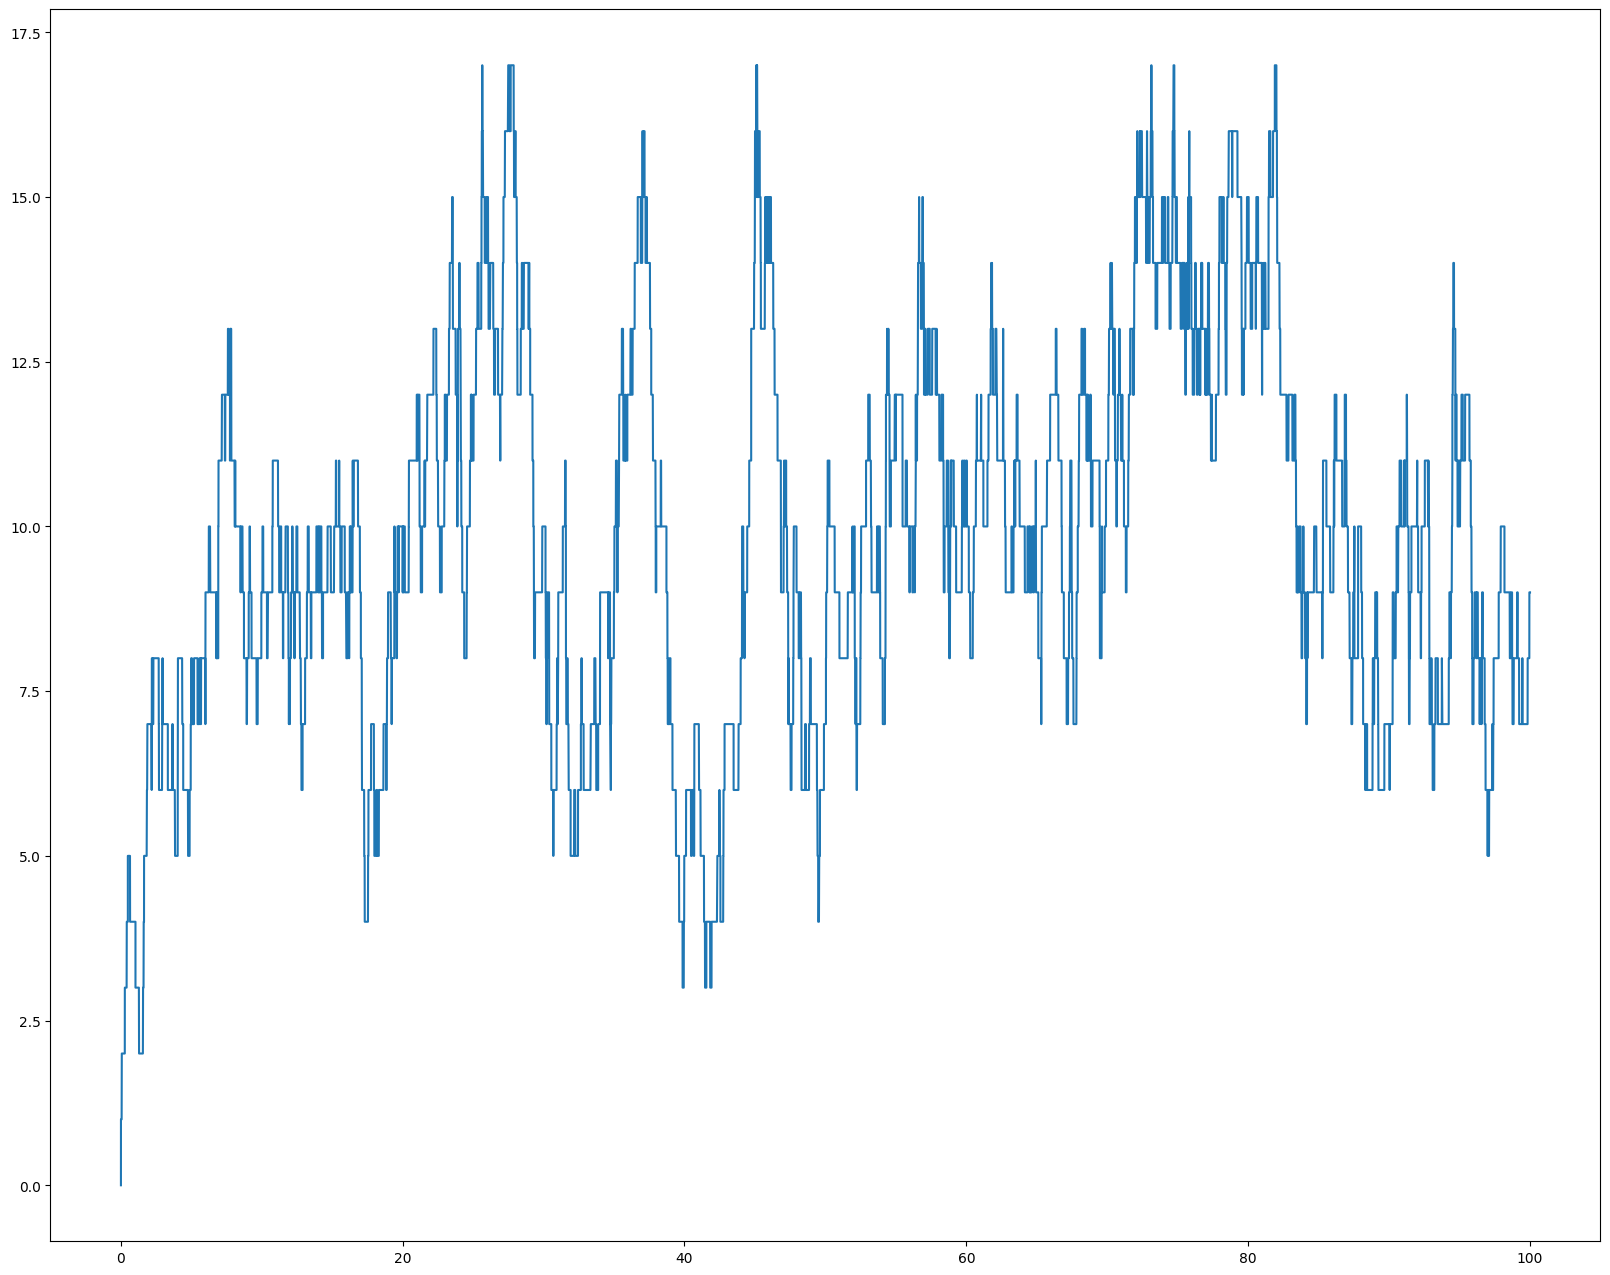

In [ ]:
plt.figure(figsize=(20,16))
plt.plot(used1.keys(),used1.values(),label='Edge')
plt.show

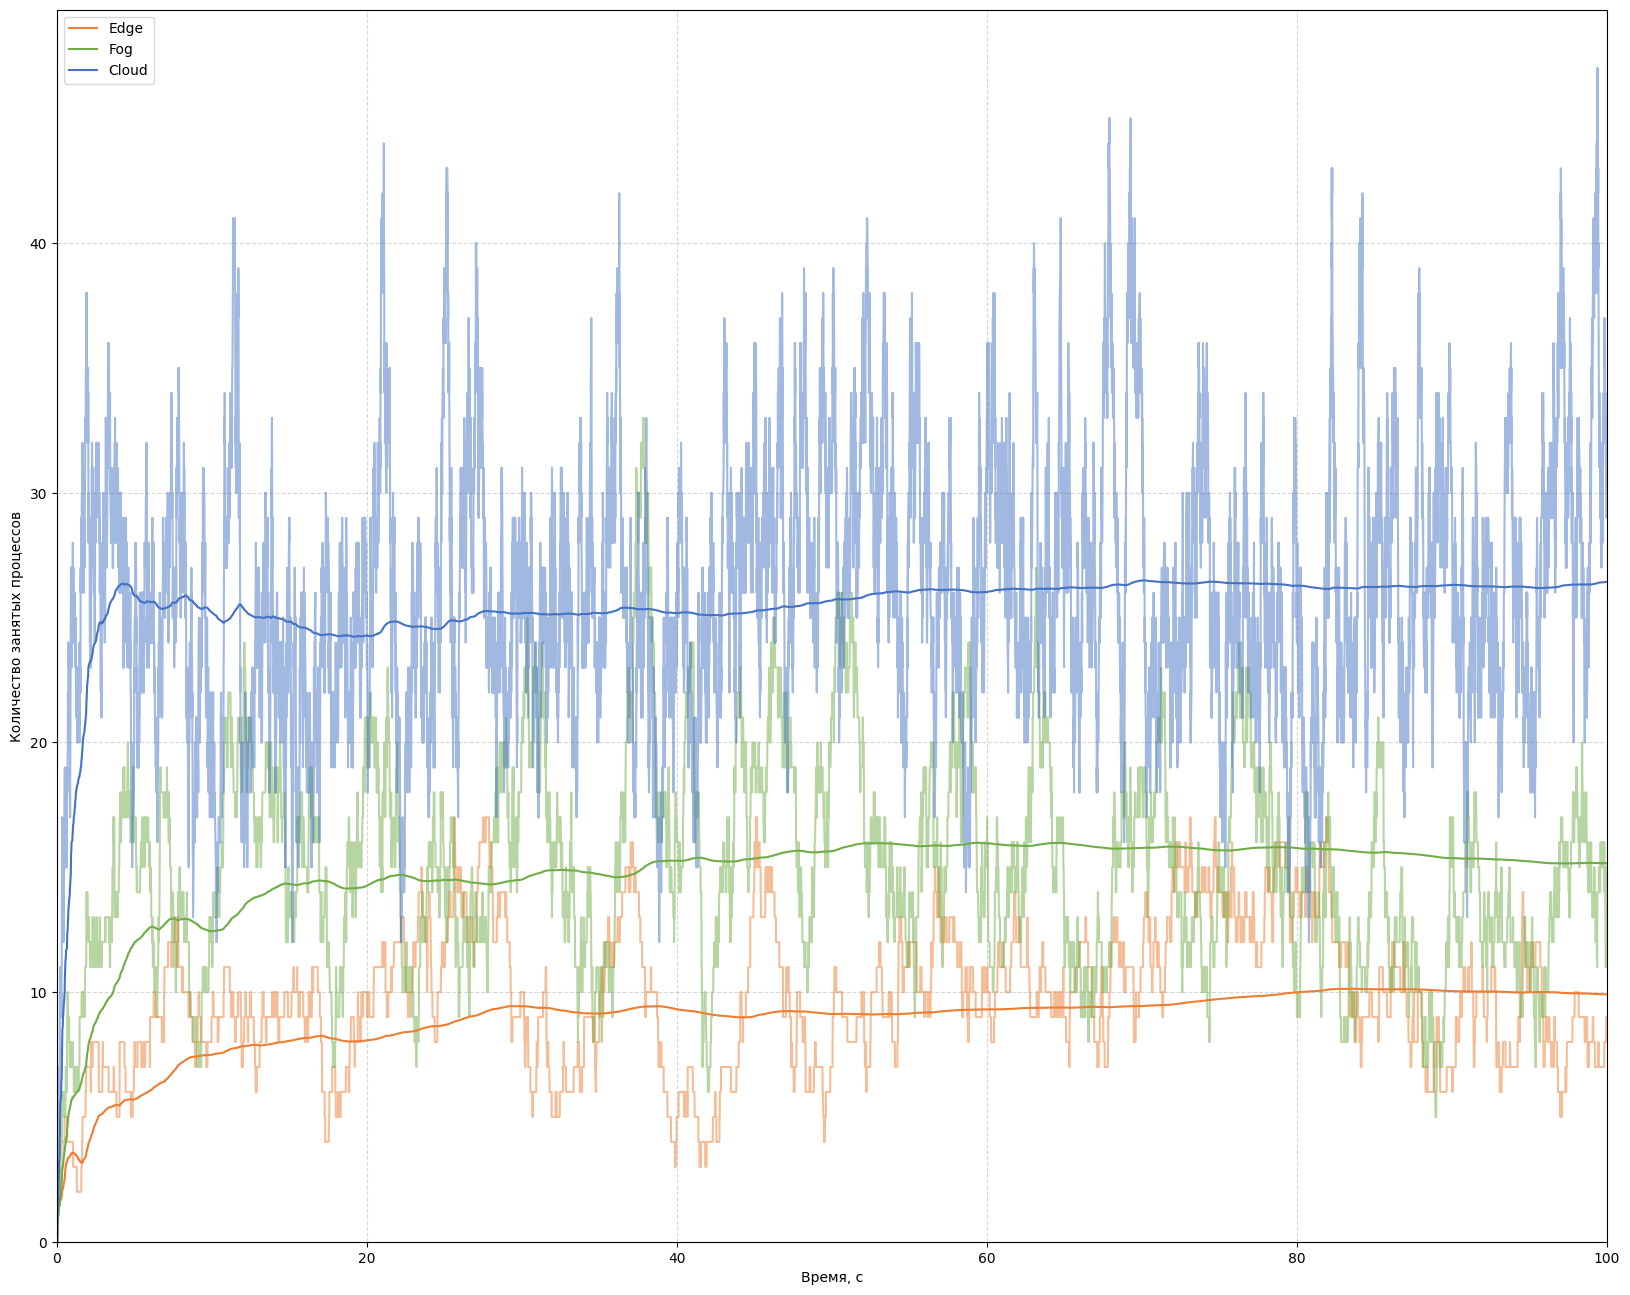

In [ ]:
plt.figure(figsize=(20,16))

plt.plot(used1.keys(),used1.values(),alpha=0.5,color='#ED7D31' )
plt.plot(used2.keys(),used2.values(),alpha=0.5,color='#70AD47' )
plt.plot(used3.keys(),used3.values(),alpha=0.5,color='#4472C4' )

plt.plot(ma1.keys(),ma1.values(),label='Edge',color='#ED7D31' )
plt.plot(ma2.keys(),ma2.values(),label='Fog',color='#70AD47' )
plt.plot(ma3.keys(),ma3.values(),label='Cloud',color='#4472C4')

plt.xlim(0,sim_time)
plt.ylim(0,)
plt.xlabel('Время, c')
plt.ylabel('Количество занятых процессов')
plt.grid(linestyle = '--', alpha = 0.5)
plt.legend()
plt.show()



> 4.2 Гистограммы распределения



In [ ]:
m1 = list(ma1.values())[-1]
m2 = list(ma2.values())[-1]
m3 = list(ma3.values())[-1]

q1 = np.quantile(list(used1.values()),0.99)
q2 = np.quantile(list(used2.values()),0.99)
q3 = np.quantile(list(used3.values()),0.99)

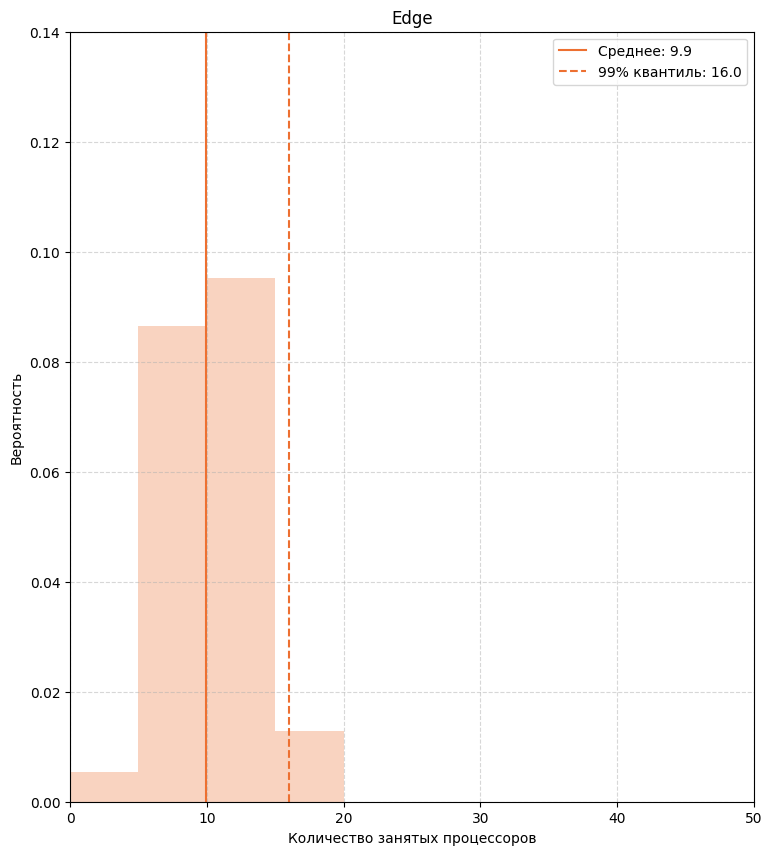

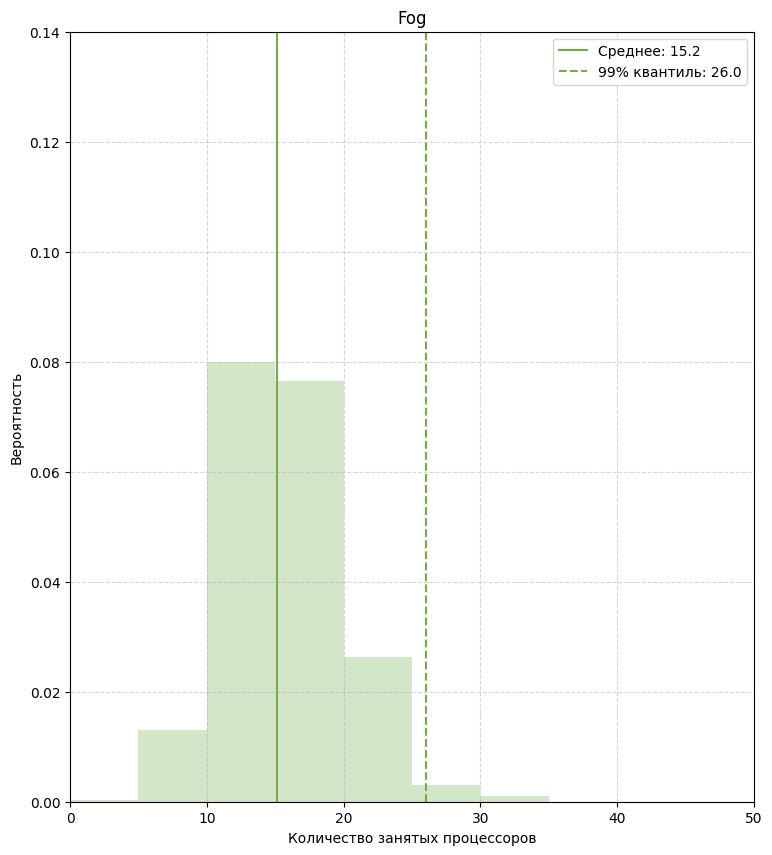

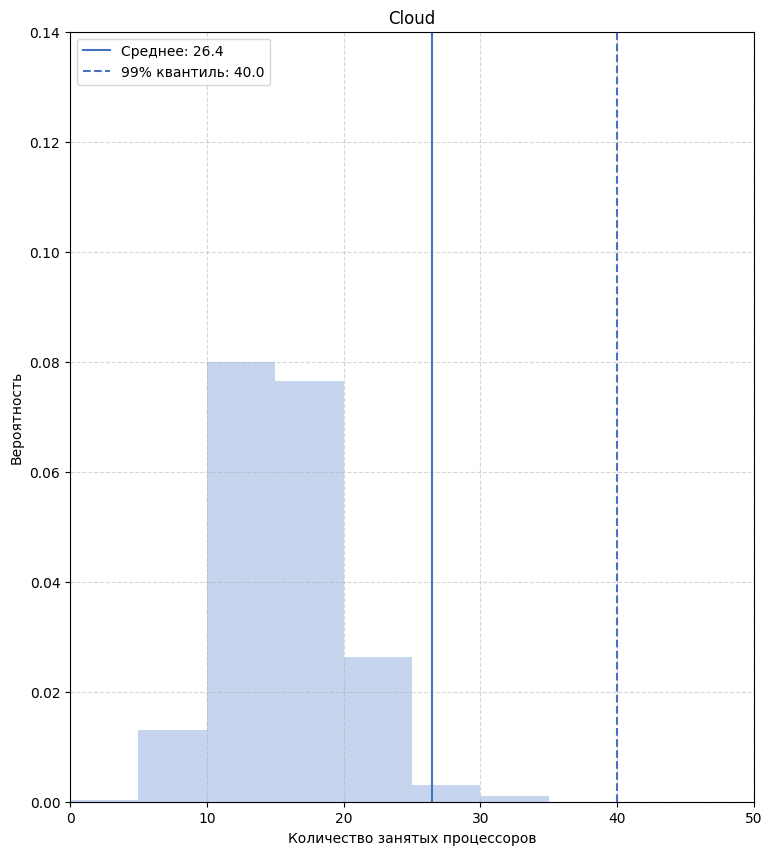

In [ ]:
plt.figure(figsize=(30,10))
plt.subplot(1,3,1)
plt.hist(used1.values(),bins=np.linspace(0,100,21), density=True, color='#ED7031', alpha=0.3)
plt.axvline(m1,color='#ED7031', label=f'Среднее: {m1:.1f}')
plt.axvline(q1,color='#ED7031', label=f'99% квантиль: {q1:.1f}', linestyle='--')
plt.grid(linestyle='--', alpha=0.5)
plt.xlim(0,50)
plt.ylim(0,0.14)
plt.xlabel('Количество занятых процессоров')
plt.ylabel('Вероятность')
plt.legend()
plt.title('Edge')
plt.show()

plt.figure(figsize=(30,10))
plt.subplot(1,3,2)
plt.hist(used2.values(), bins=np.linspace(0,100,21), density=True, color='#70AD47', alpha=0.3)
plt.axvline(m2, color='#70AD47', label=f'Среднее: {m2:.1f}')
plt.axvline(q2, color='#70AD47', label=f'99% квантиль: {q2:.1f}', linestyle='--')
plt.grid(linestyle='--', alpha=0.5)
plt.xlim(0,50)
plt.ylim(0,0.14)
plt.xlabel('Количество занятых процессоров')
plt.ylabel('Вероятность')
plt.legend()
plt.title('Fog')
plt.show()

plt.figure(figsize=(30,10))
plt.subplot(1,3,3)
plt.hist(used2.values(), bins=np.linspace(0,100,21), density=True, color='#4472C4', alpha=0.3)
plt.axvline(m3, color='#4472C4', label=f'Среднее: {m3:.1f}')
plt.axvline(q3, color='#4472C4', label=f'99% квантиль: {q3:.1f}', linestyle='--')
plt.grid(linestyle='--', alpha=0.5)
plt.xlim(0,50)
plt.ylim(0,0.14)
plt.xlabel('Количество занятых процессоров')
plt.ylabel('Вероятность')
plt.legend()
plt.title('Cloud')
plt.show()

# 5. Выводы



> Cloud обрабатывает 80% задач ; Fog обрабатывает 15% задач ; Edge обрабатывает всего 5% задач

> Текущее распределение производительности эффективно.

- Наиболее производительные ресурсы (Cloud) получают наибольшую нагрузку

- Менее производительные (Edge) используются для простых задач

- Fog служит промежуточным звеном

> Система спроектирована оптимально для заданных параметров !









